# pptime-server test

In [1]:
import requests
import time

service_url = "http://219.222.20.79:31063"

def record(api, stage_id, req_id, desc):
    data = {
        "stage_id": stage_id,
        "req_id": req_id,
        "desc": desc
    }
    try:
        response = requests.post(
            f"{service_url}/{api}",
            json=data,
            timeout=5
        )
        return response.status_code == 200
    except requests.exceptions.RequestException as e:
        print(f"Record Failed: {e}")
        return False

def collect_data():
    try:
        response = requests.post(
            f"{service_url}/collect",
            timeout=5
        )
        if response.status_code == 200:
            return response.json()
        else:
            print(f"Collect Failed, State Code: {response.status_code}")
            return None
    except requests.exceptions.RequestException as e:
        print(f"Collect Failed: {e}")
        return None


# record('start', 0, 1, 1)
# time.sleep(2)
# record('end', 0, 1, 1)

# record('start', 0, 1, 2)
# time.sleep(1)
# record('end', 0, 1, 2)

# print(collect_data())

try:
    response = requests.get(
        f"{service_url}/status",
        timeout=5
    )
    if response.status_code == 200:
        print(response.json())
    else:
        print(f"Collect Failed, State Code: {response.status_code}")
except requests.exceptions.RequestException as e:
    print(f"Collect Failed: {e}")

{'total_records': 16, 'pending_starts': 0, 'records': [[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []], 'start_times': {}}


# pp_gantte drawing test

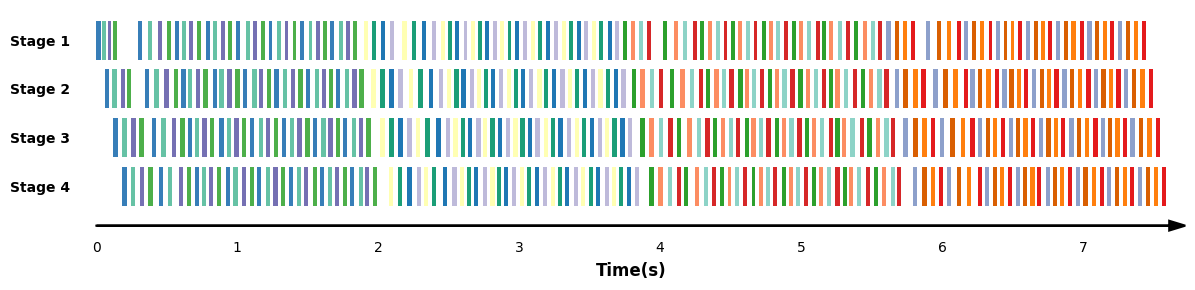

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import csv
import os

x_max_global = -1

def load_records_from_csv_auto(filename):
    records = []
    
    def convert_value(value):
        """尝试自动转换数据类型"""
        try:
            # 尝试转换为整数
            return int(value)
        except ValueError:
            try:
                # 尝试转换为浮点数
                return float(value)
            except ValueError:
                # 保持为字符串
                return value
    
    try:
        with open(filename, 'r', encoding='utf-8') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                # 转换所有值为适当的数据类型
                converted_values = [convert_value(row[field]) for field in reader.fieldnames]
                record_tuple = tuple(converted_values)
                records.append(record_tuple)
        return records
    
    except Exception as e:
        print(f"读取文件时出错：{e}")
        return []


def get_percentile_data_from_array(data_array, left, right):
    """
    从数组数据中按照第一列id分组，提取每个id的left%-right%区间的数据
    
    Parameters:
    data_array: 包含数据的数组
    
    Returns:
    包含所有id的left%-right%区间数据的数组
    """
    import numpy as np
    
    # 确保数据是numpy数组
    data = np.array(data_array)
    
    # 获取唯一的id值
    unique_ids = np.unique(data[:, 0])
    
    result_rows = []
    
    for id_value in unique_ids:
        id_rows = data[data[:, 0] == id_value]

        total_rows = len(id_rows)
        start_idx = int(np.floor(total_rows * left))
        end_idx = int(np.ceil(total_rows * right))
        
        percentile_data = id_rows[start_idx:end_idx]
        result_rows.extend(percentile_data)
    
    return np.array(result_rows)


def draw_pp_gantte(
    filepath: str, 
    t_begin = 1, 
    t_end = None, 
    xtick: bool = False, 
    xtick_space: float = 0.1, 
    left: float = 0.0,
    right: float = 1.0
):
    '''
    根据给定csv数据，绘制流水线并行甘特图
    参数：
    filepath：csv数据文件路径
    t_begin：从第几个token开始绘制
    t_end：在第几个token结束绘制
    xtick：是否绘制x轴刻度值
    xtick_space：x轴刻度密集程度
    '''
    raw_data = load_records_from_csv_auto(filepath)
    init_timestamp = raw_data[0][3]
    
    raw_data = get_percentile_data_from_array(raw_data, left, right)
    
    # 获取所有唯一的ID
    unique_ids = list(set([req_id for _, req_id, _, _, _, _ in raw_data]))
    unique_desc = list(set([desc for _, _, desc, _, _, _ in raw_data]))

    data = [
        (
            f"Stage {int(stage_id+1)}",
            req_id,
            start - init_timestamp,
            duration,
            f"t{desc}"
        )
        for stage_id, req_id, desc, start, end, duration in raw_data if desc in unique_desc[t_begin-1:t_end]
    ]

    fig, ax = plt.subplots(figsize=(12, 3))
    colors = ["#FFAAAA", "#ACE7E3", "#95D0DD", "#CAE2AE", "#ecb49a", "#ebe18f", "#b09beb", "#dc97e6"]
    edgecolor = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#90D145', "#e9753f", "#cfc033", "#6640cf", "#be40cf"]

    # 选择颜色映射 - 使用对比度强的colormap
    colormaps = ['tab10', 'Set1', 'Set2', 'Set3', 'Dark2']  # 这些colormap颜色差异较大
    colors = []
    # 从不同的colormap中选取颜色，确保颜色差异大
    for i, id_val in enumerate(unique_ids):
        cmap = plt.get_cmap(colormaps[i % len(colormaps)])
        color = cmap((i // len(colormaps)) % cmap.N)
        colors.append(color)
    # 创建ID到颜色的映射
    id_to_color = {id_val: colors[i%len(colors)] for i, id_val in enumerate(unique_ids)}
    id_to_edgecolor = {id_val: edgecolor[i%len(edgecolor)] for i, id_val in enumerate(unique_ids)}

    for stage, rid, start, duration, desc in data:
        ax.barh(
            stage,
            duration,
            left=start,
            height=0.8,
            color=id_to_color[rid],
            # edgecolor=id_to_edgecolor[rid],
            linewidth=1.5,
        )

        # 计算文字位置（柱状图中心）
        # text_x = start + duration / 2
        # text_y = stage
        # ax.text(
        #     text_x, text_y, desc, 
        #     ha='center',        # 水平居中
        #     va='center',        # 垂直居中
        #     color='black',      # 文字颜色（与背景对比）
        #     fontweight='bold',  # 文字加粗
        #     fontsize=10             # 文字大小
        # )

    # 反转y轴顺序
    ax.invert_yaxis()
    # 自动计算合适的结束值
    x_max = max([start + duration for _, _, start, duration, _ in data])   # 计算最大x值
    # print(x_max)
    global x_max_global
    if x_max > x_max_global:
        x_max_global = x_max
    else:
        x_max = x_max_global
    ax.set_xlim(None, x_max)
    # 加粗横轴线
    # ax.spines['bottom'].set_linewidth(2)
    # 去除所有刻度线
    ax.tick_params(axis='both', which='both', length=0)  # 刻度线长度为0
    # 隐藏横坐标刻度值
    ax.tick_params(axis='x', labelbottom=xtick, pad=0)
    # ax.xaxis.set_major_locator(ticker.MultipleLocator(xtick_space))
    # 加粗纵坐标刻度值
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_x(-0.02)
    # 只保留底部和右侧的轴线，隐藏顶部和左侧
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    # 添加向右箭头
    offset = data[0][2]
    ax.arrow(
        offset, 3.8, x_max-offset+0.02, 0,
        head_width=0.2, head_length=0.015*(x_max-offset),
        fc='black', ec='black', linewidth=1.5, clip_on=False
    )

    ax.set_xlabel('Time(s)', fontweight='bold', fontsize=12, labelpad=5, loc='center')
    # ax.set_ylabel('Stages')
    plt.tight_layout()
    plt.show()


def get_latest_csv(directory):
    files = [os.path.join(directory, f) for f in os.listdir(directory)]
    files = [f for f in files 
             if os.path.isfile(f) 
             and os.path.basename(f).startswith("pp-records") 
             and f.lower().endswith('.csv')]
    if not files:
        return None
    latest_file = max(files, key=os.path.getctime)
    return latest_file

def get_csv_by_idx(directory, idx):
    files = [os.path.join(directory, f) for f in os.listdir(directory)]
    files = [f for f in files 
             if os.path.isfile(f) 
             and os.path.basename(f).startswith("pp-records") 
             and f.lower().endswith('.csv')]
    if not files:
        return None
    sorted_files = sorted(files, key=os.path.getctime, reverse=True)
    return sorted_files[idx]

# 存放csv数据的根目录
base_dir = os.path.join("/home/austin/repos/AdaptSplit/evals/stats/", "testing")
# 绘制甘特图
# draw_pp_gantte(get_latest_csv(base_dir), xtick=True)
# draw_pp_gantte(get_csv_by_idx(base_dir, 2), t_begin=1, xtick=True)
# draw_pp_gantte(os.path.join(base_dir, 'pp-records_2025-12-10_01-01-30.csv'), t_begin=1, xtick=True)

left = 0
right = 1

# draw_pp_gantte(os.path.join(base_dir, 'pp-records_2026-03-07_19-23-19.csv'), t_begin=1, xtick=True, left=left, right=right)
draw_pp_gantte(get_csv_by_idx(base_dir, 0), t_begin=1, xtick=True, left=left, right=right)

# pipeline predictor plotting

In [ ]:
'''
该脚本将 从 num_layer->不同batch_sizes 的映射数据，反转为从 batch_size->不同num_layers 的映射数据，方便绘图比较
'''

from collections import defaultdict
import json


def transform_by_batch_size(data):
    """
    将原始格式：
      - 每个元素对应一个 num_layer
      - batch_sizes 是一组批次
      - batch_latencys_ms / powers_W 的每一行对应一个 device
    转成：
      - 每个元素对应一个 batch_size
      - num_layers 是一组层数
      - batch_latencys_ms / powers_W 的每一行仍对应一个 device，
        但列方向变成不同 num_layer 的值
    """

    # 按 (model, devices, n_input_tokens, n_output_tokens) 分组
    groups = defaultdict(list)
    for item in data:
        key = (
            item["model"],
            tuple(item["devices"]),
            item["n_input_tokens"],
            item["n_output_tokens"],
        )
        groups[key].append(item)

    result = []

    for (model, devices, n_input_tokens, n_output_tokens), items in groups.items():
        # 按 num_layer 排序，保证输出的 num_layers 有序
        items = sorted(items, key=lambda x: x["num_layer"])
        num_layers = [item["num_layer"] for item in items]

        # 默认假设同组内 batch_sizes 一致
        batch_sizes = items[0]["batch_sizes"]
        n_devices = len(devices)

        # 遍历每个 batch_size
        for batch_idx, batch_size in enumerate(batch_sizes):
            new_item = {
                "model": model,
                "devices": list(devices),
                "num_layers": num_layers,
                "batch_size": batch_size,
                "n_input_tokens": n_input_tokens,
                "n_output_tokens": n_output_tokens,
                "batch_latencys_ms": [],
                "powers_W": [],
            }

            # 对每个 device，收集所有 num_layer 下当前 batch_size 的值
            for device_idx in range(n_devices):
                lat_list = []
                power_list = []

                for item in items:
                    lat_list.append(item["batch_latencys_ms"][device_idx][batch_idx])
                    power_list.append(item["powers_W"][device_idx][batch_idx])

                new_item["batch_latencys_ms"].append(lat_list)
                new_item["powers_W"].append(power_list)

            result.append(new_item)

    return result



# 读取原始 json 文件
with open("/home/austin/repos/AdaptSplit/evals/stats/jsons/2026-03-09_22-18-27.json", "r", encoding="utf-8") as f:
    data = json.load(f)

transformed = transform_by_batch_size(data)

# 保存转换后的结果
with open("/home/austin/repos/AdaptSplit/evals/stats/jsons/2026-03-09_22-18-27-inverted.json", "w", encoding="utf-8") as f:
    json.dump(transformed, f, ensure_ascii=False, indent=4)

print("转换完成")

In [ ]:
'''
根据Pre-Benchmark的真实测试数据，绘制图像，分别绘制：
- 固定num_layer下，不同batch_size的测试表现
- 固定batch_size下，不同num_layer的测试表现
'''

import matplotlib.pyplot as plt
import json
from typing import Dict, Any, List
import numpy as np


def get_json_data(file_path: str) -> List[Dict[str, Any]]:
        """
        获取JSON文件中的所有数组数据
        :return: 列表格式的数据，每个元素是字典
        """
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                # 确保返回的是列表类型
                return data if isinstance(data, list) else []
        except Exception as e:
            print(f"读取JSON文件失败: {e}")
            return []

def custom_scale(x):
    return np.sqrt(x)

def plot(
    xticks: List[int],
    latency_data: List[List[float]],
    power_data: List[List[float]],
    devices: List[str],
    title: str,
    xlabel: str,
    xscale: bool,
    custom_xticks: List[int] = None
):
    # 创建一个大的图像，包含两个子图
    plt.figure(figsize=(8, 3))

    # 第一个子图（延迟）
    plt.subplot(1, 2, 1)  # 1行2列，第1个位置
    for i, data in enumerate(latency_data):
        data = [d for d in data]
        plt.plot(xticks, data, label=devices[i], marker='o', linewidth=2)

    # 添加参考线 - 基于jetson-64g-4设备（第一个设备）的num layers=1时延值
    # base_latency = latency_data[0][0]  # 获取jetson-64g-4在num layers=1的时延（转换为ms）
    # reference_line = [base_latency * n for n in xticks]  # 成倍增长参考线
    # plt.plot(xticks, reference_line, '--', color='gray', linewidth=1.5)
    # plt.ylim(0,35)

    plt.title(f'Batch Latency Curve ({title})')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Batch Latency (ms)', fontsize=12)
    if xscale:
        plt.xscale('function', functions=(custom_scale, np.square))
    plt.xticks(custom_xticks if custom_xticks else xticks)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize='small', loc="upper left")

    # 第二个子图（功耗）
    plt.subplot(1, 2, 2)  # 1行2列，第2个位置
    for i, data in enumerate(power_data):
        plt.plot(xticks, data, label=devices[i], marker='o', linewidth=2)
    plt.title(f'Power Curve ({title})')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Avg. Power (W)', fontsize=12)
    if xscale:
        plt.xscale('function', functions=(custom_scale, np.square))
    plt.xticks(custom_xticks if custom_xticks else xticks)
    plt.grid(True, alpha=0.3)
    # plt.legend()

    plt.tight_layout()
    plt.show()


def plot_from_json(json_path: str):
    full_data = get_json_data(json_path)
    for stat in full_data:
        if "num_layers" in stat:
            xticks = stat["num_layers"]
            fixed = stat["batch_size"]
            title = f"Batch Size = {fixed}"
            xlabel = "Num Layer"
            xscale = False
        if "batch_sizes" in stat:
            xticks = stat["batch_sizes"]
            fixed = stat["num_layer"]
            title = f"Num Layer = {fixed}"
            xlabel = "Batch Size"
            xscale = True
        latency_data = stat["batch_latencys_ms"]
        power_data = stat["powers_W"]
        devices = stat["devices"]
        devices = ["Jetson AGX Orin", "Jetson Orin NX", "Jetson Orin NX", "Jetson Orin Nano"]
        plot(
            xticks,
            latency_data,
            power_data,
            devices,
            title,
            xlabel,
            xscale,
            # [1,16,32,64,128,256]
        )

# 固定num_layer下，不同batch_size的测试表现
plot_from_json("/home/austin/repos/AdaptSplit/evals/stats/jsons/2026-03-09_22-18-27.json")
# 固定batch_size下，不同num_layer的测试表现
plot_from_json("/home/austin/repos/AdaptSplit/evals/stats/jsons/2026-03-09_22-18-27-inverted.json")

In [ ]:
'''
根据训练好的预测器所预测的数据，绘制图像，分别绘制：
- 固定num_layer下，不同batch_size的测试表现
- 固定batch_size下，不同num_layer的测试表现

为了展示预测器的拟合效果，对比 预测数据图像 和 真实数据图像
'''
import argparse
import copy
import json
import math
import os
import random
import re
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn

class LatencyPowerPredictor(nn.Module):
    def __init__(self, input_dim: int = 2, hidden_dims: Tuple[int, ...] = (64, 64, 32), dropout: float = 0.05):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)
        layers: List[nn.Module] = []
        for in_dim, out_dim in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.SiLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

@dataclass
class PredictorBundle:
    model: LatencyPowerPredictor
    x_mean: np.ndarray
    x_std: np.ndarray
    y_mean: np.ndarray
    y_std: np.ndarray
    model_name: str
    device_name: str

    @torch.no_grad()
    def predict(self, num_layer: float, batch_size: float, device: str = "cuda") -> Tuple[float, float]:
        self.model.eval()
        x = np.array([[float(num_layer), float(batch_size)]], dtype=np.float32)
        x_norm = (x - self.x_mean) / self.x_std
        x_tensor = torch.tensor(x_norm, dtype=torch.float32, device=device)
        y_norm = self.model(x_tensor).cpu().numpy()
        y = y_norm * self.y_std + self.y_mean
        latency_ms, power_w = y[0].tolist()
        latency_ms = max(float(latency_ms), 0.0)
        power_w = max(float(power_w), 0.0)
        return latency_ms, power_w

def load_predictor(checkpoint_path: str, device: str = "cuda") -> PredictorBundle:
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = LatencyPowerPredictor(
        hidden_dims=tuple(ckpt["hidden_dims"]),
        dropout=float(ckpt["dropout"]),
    ).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    return PredictorBundle(
        model=model,
        x_mean=np.asarray(ckpt["x_mean"], dtype=np.float32),
        x_std=np.asarray(ckpt["x_std"], dtype=np.float32),
        y_mean=np.asarray(ckpt["y_mean"], dtype=np.float32),
        y_std=np.asarray(ckpt["y_std"], dtype=np.float32),
        model_name=ckpt["model_name"],
        device_name=ckpt["device_name"],
    )

def get_predictor(model_name: str, device_name: str):
    return load_predictor(f"/home/austin/repos/AdaptSplit/AdaptSplit/uneven_partitioning/checkpoints/{model_name}-{device_name}.pt", device="cuda")
    # latency_ms, power_w = predictor.predict(num_layer=7, batch_size=100)

predictors = {}
for device in ['jetson-64g-4', 'jetson-16g-2', 'jetson-16g-8', 'jetson-8g-1']:
    model_name = 'Llama-2-7b-chat-hf'
    predictors[(model_name, device)] = get_predictor(model_name, device)

def get_json_data(file_path: str) -> List[Dict[str, Any]]:
        """
        获取JSON文件中的所有数组数据
        :return: 列表格式的数据，每个元素是字典
        """
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                # 确保返回的是列表类型
                return data if isinstance(data, list) else []
        except Exception as e:
            print(f"读取JSON文件失败: {e}")
            return []

def custom_scale(x):
    return np.sqrt(x)

def plot(
    xticks: List[int],
    latency_data: List[List[float]],
    power_data: List[List[float]],
    devices: List[str],
    title: str,
    xlabel: str,
    xscale: bool,
    custom_xticks: List[int] = None
):
    # 创建一个大的图像，包含两个子图
    plt.figure(figsize=(8, 3))

    # 第一个子图（延迟）
    plt.subplot(1, 2, 1)  # 1行2列，第1个位置
    for i, data in enumerate(latency_data):
        data = [d for d in data]
        plt.plot(xticks, data, label=devices[i], marker='o', linewidth=2)

    plt.title(f'Batch Latency Curve ({title})')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Batch Latency (ms)', fontsize=12)
    if xscale:
        plt.xscale('function', functions=(custom_scale, np.square))
    plt.xticks(custom_xticks if custom_xticks else xticks)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize='small', loc="upper left")

    # 第二个子图（功耗）
    plt.subplot(1, 2, 2)  # 1行2列，第2个位置
    for i, data in enumerate(power_data):
        plt.plot(xticks, data, label=devices[i], marker='o', linewidth=2)
    plt.title(f'Power Curve ({title})')
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Avg. Power (W)', fontsize=12)
    if xscale:
        plt.xscale('function', functions=(custom_scale, np.square))
    plt.xticks(custom_xticks if custom_xticks else xticks)
    plt.grid(True, alpha=0.3)
    # plt.legend()

    plt.tight_layout()
    plt.show()

def comp_predictor_n_real(json_path: str):
    full_data = get_json_data(json_path)
    for stat in full_data:
        if "num_layers" in stat:
            xticks = stat["num_layers"]
            fixed = stat["batch_size"]
            title = f"Batch Size = {fixed}"
            xlabel = "Num Layer"
            xscale = False
        if "batch_sizes" in stat:
            xticks = stat["batch_sizes"]
            fixed = stat["num_layer"]
            title = f"Num Layer = {fixed}"
            xlabel = "Batch Size"
            xscale = True
        latency_data = stat["batch_latencys_ms"]
        power_data = stat["powers_W"]
        devices = stat["devices"]
        devices = ["Jetson AGX Orin", "Jetson Orin NX", "Jetson Orin NX", "Jetson Orin Nano"]
        print("Plot from Real Data:")
        plot(
            xticks,
            latency_data,
            power_data,
            devices,
            title,
            xlabel,
            xscale,
            # [1,16,32,64,128,256]
        )
        
        # 对比预测器数据
        latency_data = []
        power_data = []
        devices = stat["devices"]
        for device in devices:
            latencys = []
            powers = []
            for xx in xticks:
                if "num_layers" in stat:
                    latency_ms, power_w = predictors[(stat["model"], device)].predict(num_layer=xx, batch_size=fixed)
                elif "batch_sizes" in stat:
                    latency_ms, power_w = predictors[(stat["model"], device)].predict(num_layer=fixed, batch_size=xx)
                latencys.append(latency_ms)
                powers.append(power_w)
            latency_data.append(latencys)
            power_data.append(powers)
        devices = ["Jetson AGX Orin", "Jetson Orin NX", "Jetson Orin NX", "Jetson Orin Nano"]
        print("Plot from Predictor:")
        plot(
            xticks,
            latency_data,
            power_data,
            devices,
            title,
            xlabel,
            xscale,
            # [1,16,32,64,128,256]
        )

# 固定num_layer下，不同batch_size的测试表现（真实数据和预测数据对比）
comp_predictor_n_real("/home/austin/repos/AdaptSplit/evals/stats/jsons/2026-03-09_22-18-27.json")
# 固定batch_size下，不同num_layer的测试表现（真实数据和预测数据对比）
comp_predictor_n_real("/home/austin/repos/AdaptSplit/evals/stats/jsons/2026-03-09_22-18-27-inverted.json")